# Mutual Fund Analytics

## Exploratory Data Analysis (EDA)

**Project:** Bluestock Fintech Internship – Mutual Fund Analytics

**Objective:**
Perform exploratory data analysis on cleaned mutual fund datasets to uncover trends, patterns, and insights using statistical analysis and visualizations.

---------------------------------

## Dataset Used

- Fund Master
- NAV History
- AUM by Fund House
- Monthly SIP Inflows
- Category Inflows
- Industry Folio Count
- Scheme Performance
- Investor Transactions
- Portfolio Holdings
- Benchmark Indices

----------------------------

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Jupyter Notebook

# 1. Import Required Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# 2. Load Cleaned Datasets

In [2]:

DATA_DIR = Path("../data/processed")
fund_master = pd.read_csv(DATA_DIR / "01_fund_master_cleaned.csv")

nav = pd.read_csv(DATA_DIR / "02_nav_history_cleaned.csv")

aum = pd.read_csv(DATA_DIR / "03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv(DATA_DIR / "04_monthly_sip_inflows_cleaned.csv")

category = pd.read_csv(DATA_DIR / "05_category_inflows_cleaned.csv")

folio = pd.read_csv(DATA_DIR / "06_industry_folio_count_cleaned.csv")

performance = pd.read_csv(DATA_DIR / "07_scheme_performance_cleaned.csv")

transactions = pd.read_csv(DATA_DIR / "08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv(DATA_DIR / "09_portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv(DATA_DIR / "10_benchmark_indices_cleaned.csv")

# 3. Dataset Inspection (yaa!! just view that every dataset is good or not 😅)

In [11]:
# Convert date columns to datetime format

nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

# 4. NAV Trend Analysis

In [ ]:
# Combine NAV data with fund details using the common AMFI code

nav_data = pd.merge(
    nav,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_data.head()



,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [103]:
# Merge datasets
nav_data = pd.merge(
    nav,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Plotly chart
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 market correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [16]:
# Save 
fig.write_image("../charts/nav/nav_trend_analysis.png")

### Insight 1 (Based on NAV Trend Analysis-Chart)

The daily NAV trend shows an overall upward movement across most mutual fund schemes from 2022 to 2026. Most schemes experienced steady growth during 2023, while 2024 showed only minor fluctuations before the upward trend continued.

# 5. AUM Growth Analysis

In [100]:
# Extract year from date column
aum["year"] = aum["date"].dt.year

# record for each fund house in every year
aum_yearly = (
    aum.sort_values("date")
       .groupby(["year", "fund_house"])
       .last()
       .reset_index()
)

aum_yearly.head()

,year,fund_house,date,aum_lakh_crore,aum_crore,num_schemes
0,2022,Aditya Birla Sun Life MF,2022-09-30,2.85,285000,199
1,2022,Axis Mutual Fund,2022-09-30,2.40,240000,95
2,2022,DSP Mutual Fund,2022-09-30,1.12,112000,88
3,2022,HDFC Mutual Fund,2022-09-30,4.45,445000,195
4,2022,ICICI Prudential MF,2022-09-30,4.88,488000,216


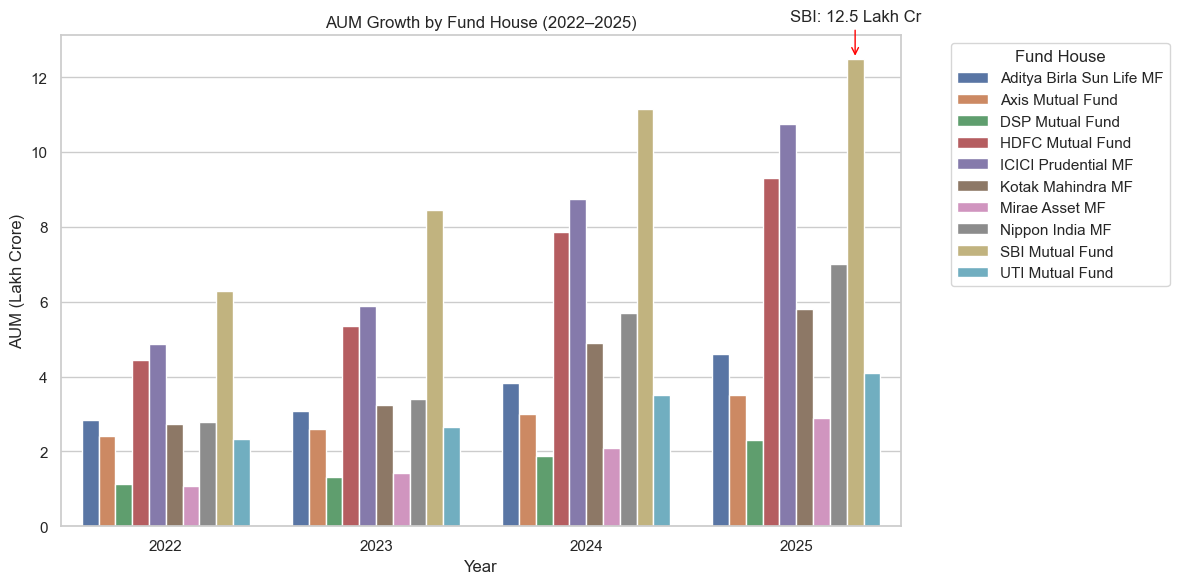

In [ ]:
# grouped bar chart
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Title and labels
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc="upper left")

# Highlight SBI Mutual Fund's highest AUM (2025)
bar = ax.patches[35]

plt.annotate(
    "SBI: 12.5 Lakh Cr",
    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
    xytext=(bar.get_x() + bar.get_width()/2, bar.get_height() + 1),
    ha="center",
    arrowprops=dict(arrowstyle="->",color="red")
)
# Save 
plt.savefig("../charts/aum/aum_growth_analysis.png",
            dpi=300,
            bbox_inches="tight")
# layout 
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# 6. SIP Inflow Analysis

In [ ]:
sip = sip.sort_values("month")
sip.head()

In [53]:
# Find the month with the highest SIP inflow
highest_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

# line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (Crore)"
    }
)

# Highlight the highest SIP inflow
fig.add_annotation(
    x=highest_sip["month"].to_pydatetime(),
    y=highest_sip["sip_inflow_crore"],
    text="Highest SIP: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    font=dict(color="red")
)
# Save 
fig.write_image("../charts/sip/sip_inflow_trend.png")
fig.show()

### Insight 3 (Based on SIP Inflow Trend)

Monthly SIP inflows increased steadily between 2022 and 2025, reflecting growing investor confidence in systematic investing. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, marking the peak of investor participation during the analysis period.

# 7. Category Inflow Analysis

In [55]:


category_heatmap.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


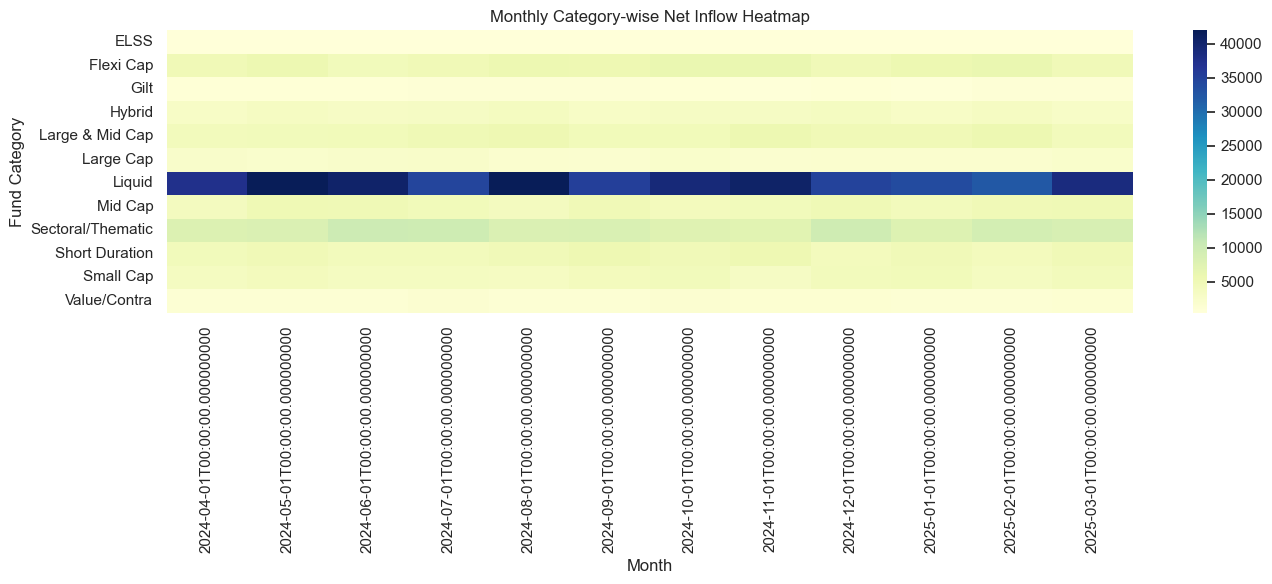

In [ ]:
# category inflow heatmap

plt.figure(figsize=(14, 6))

sns.heatmap(
    category_heatmap,
    cmap="YlGnBu",
    annot=False
)

plt.title("Monthly Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save 
plt.savefig(
    "../charts/category/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4 (Based on Category Inflow Heatmap)

Equity-oriented fund categories consistently recorded higher net inflows than other categories across the observed months. Categories such as Flexi Cap and Large & Mid Cap attracted strong investor interest, while categories like ELSS and Gilt showed comparatively lower inflows.

# 8. Investor Demographics

In [63]:
# the number of investors in each age group

age_counts = transactions["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

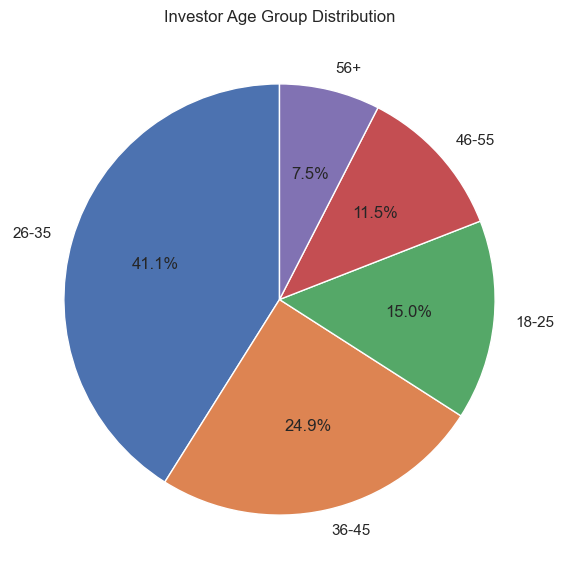

In [64]:
# a pie chart for investor age groups

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../charts/demographics/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5 (Based on Age Group Distribution)

The **26–35 years** age group represents the largest share of mutual fund investors, accounting for **41.1%** of the total investors. This indicates that young working professionals are the most active participants in mutual fund investments during the analysis period.

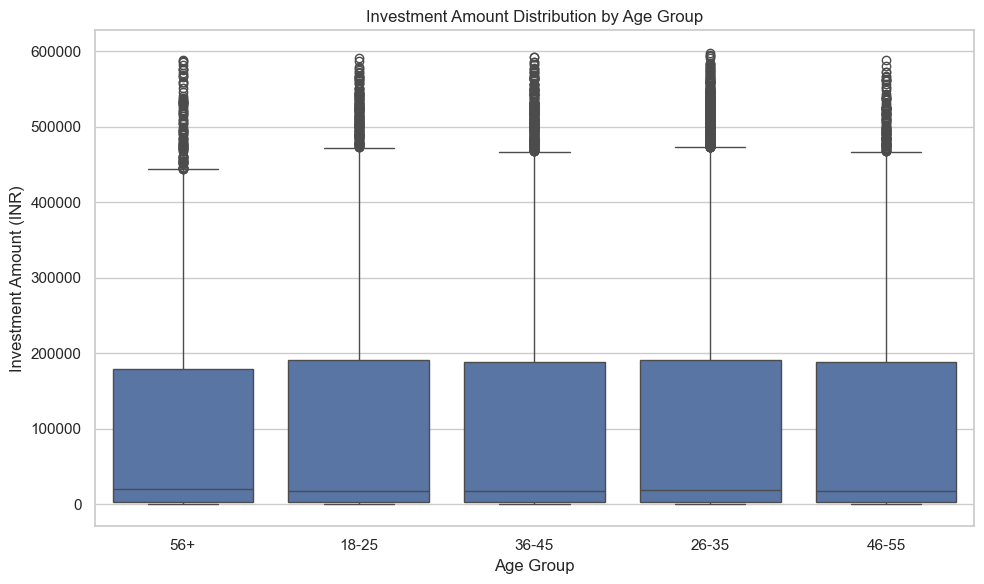

In [65]:
# a box plot of investment amount by age group

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()

# Save the chart
plt.savefig(
    "../charts/demographics/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6 (Based on Investment Amount Distribution by Age Group)

Investment amounts are broadly distributed across all age groups, with **26–35 years** showing a slightly higher median investment amount. All age groups contain several high-value outliers, indicating that a small number of investors make significantly larger investments than the majority.

In [66]:
# Count investors by gender

gender_counts = transactions["gender"].value_counts()

gender_counts


gender
Male      21809
Female    10969
Name: count, dtype: int64

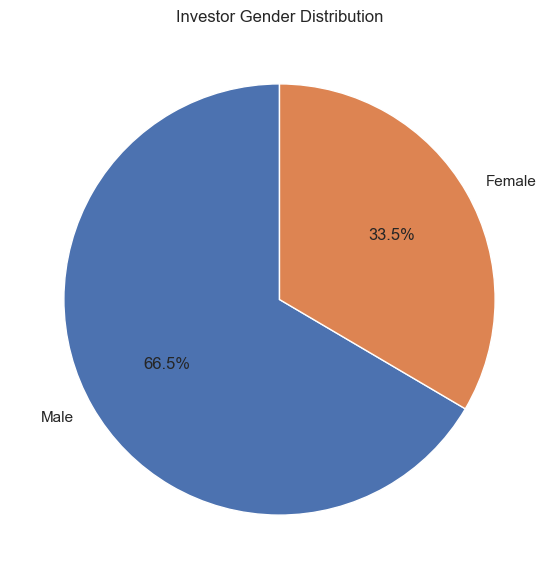

In [67]:
# a pie chart for gender distribution

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../charts/demographics/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7 (Based on Gender Distribution)

Male investors account for **66.5%** of the total investor base, while female investors represent **33.5%**. This indicates that male participation in mutual fund investments is currently higher than female participation in the analyzed dataset.

# 9. Geographic Distribution

In [68]:
# Calculate total investment amount by state

state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

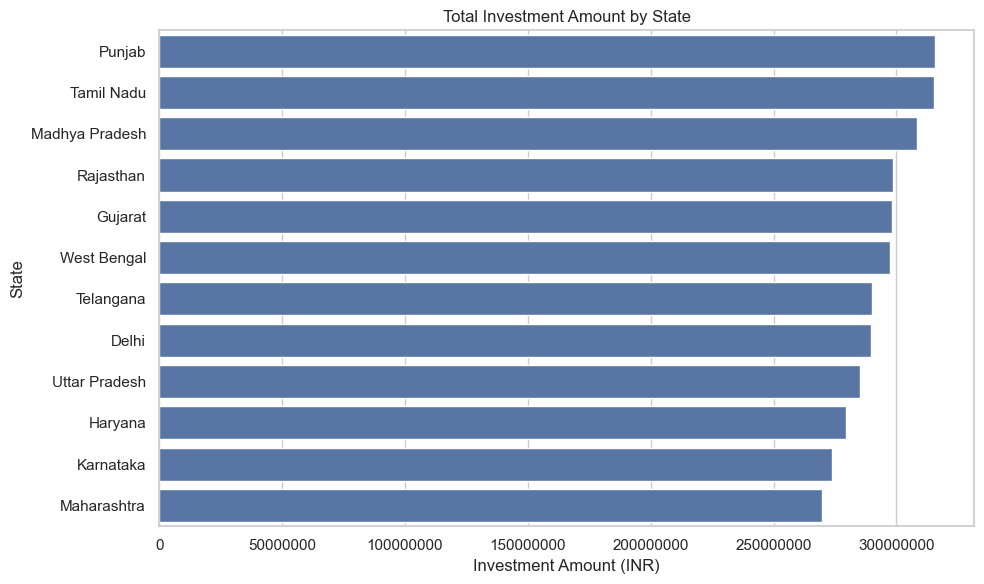

In [73]:
# a horizontal bar chart

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")
plt.ticklabel_format(style="plain", axis="x") #display full no. instead of scientific notation
plt.tight_layout()

# 
plt.savefig(
    "../charts/geographic/state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8 (Based on Investment Amount by State)

Punjab recorded the highest total investment amount among all states in the dataset, followed by Tamil Nadu and Madhya Pradesh. This indicates relatively stronger mutual fund investment activity in these states during the analysis period.

In [76]:
# Count investors by city tier
city_tier_counts = transactions["city_tier"].value_counts()
city_tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

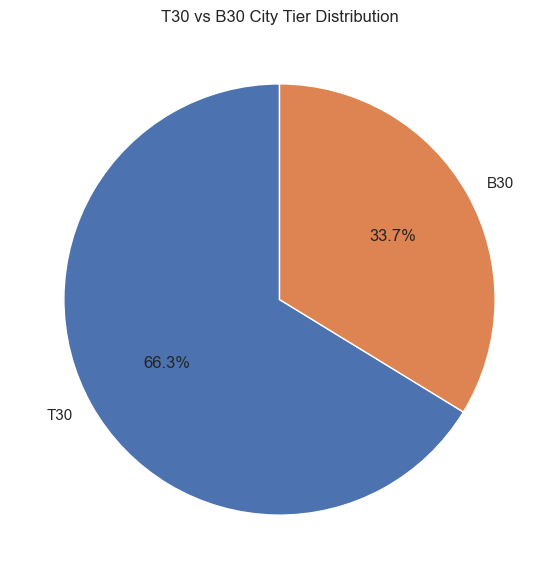

In [77]:
# a pie chart for city tier distribution

plt.figure(figsize=(7, 7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "../charts/geographic/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9 (Based on T30 vs B30 City Tier Distribution)

Investors from **T30 cities account for 66.3%** of the total investor base, while **B30 cities contribute 33.7%**. This indicates that mutual fund participation is currently more concentrated in India's top 30 cities.

# 10. Folio Count Growth

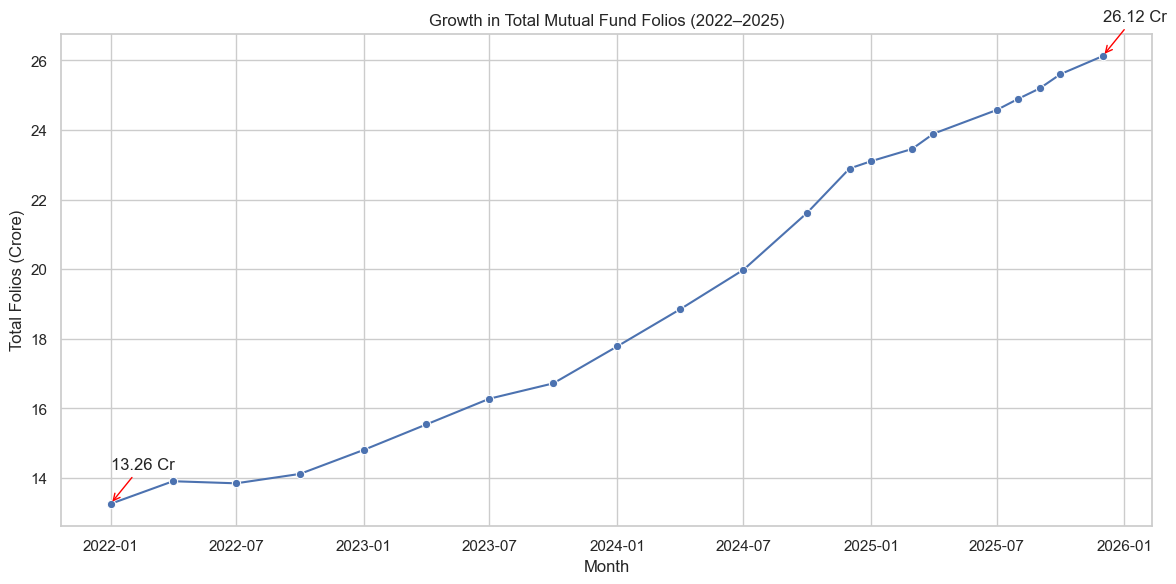

In [83]:
# Sort the data by month
folio = folio.sort_values("month")

# First and last records
start = folio.iloc[0]
end = folio.iloc[-1]

# the line chart
plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o"
)

# starting milestone
plt.annotate(
    "13.26 Cr",
    xy=(start["month"], start["total_folios_crore"]),
    xytext=(start["month"], start["total_folios_crore"] + 1),
    arrowprops=dict(arrowstyle="->",color="red")
)

# ending milestone
plt.annotate(
    "26.12 Cr",
    xy=(end["month"], end["total_folios_crore"]),
    xytext=(end["month"], end["total_folios_crore"] + 1),
    arrowprops=dict(arrowstyle="->",color="red")
)

plt.title("Growth in Total Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/folio/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 10 (Based on Folio Count Growth)

The total number of mutual fund folios increased steadily from **13.26 crore** in **January 2022** to **26.12 crore** in **December 2025**, reflecting strong growth in investor participation over the analysis period.

# 11. NAV Return Correlation

In [87]:
# Calculate the correlation between daily returns

correlation_matrix = nav_returns.corr()

correlation_matrix


scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296
SBI Bluechip Fund - Direct Plan - Growth,-0.052299,-0.027471,-0.002803,0.027796,0.013663,1.000000,-0.006819,-0.004003,-0.042415,0.020754
SBI Bluechip Fund - Regular Plan - Growth,0.030454,-0.015559,0.017017,0.016469,0.040858,-0.006819,1.000000,0.021601,-0.072559,0.024409
SBI Magnum Gilt Fund - Regular Plan - Growth,-0.016315,-0.007166,-0.040884,-0.010542,-0.022521,-0.004003,0.021601,1.000000,0.017795,0.018423
SBI Small Cap Fund - Direct Plan - Growth,0.041927,-0.028323,-0.034061,0.003347,-0.000007,-0.042415,-0.072559,0.017795,1.000000,0.018187


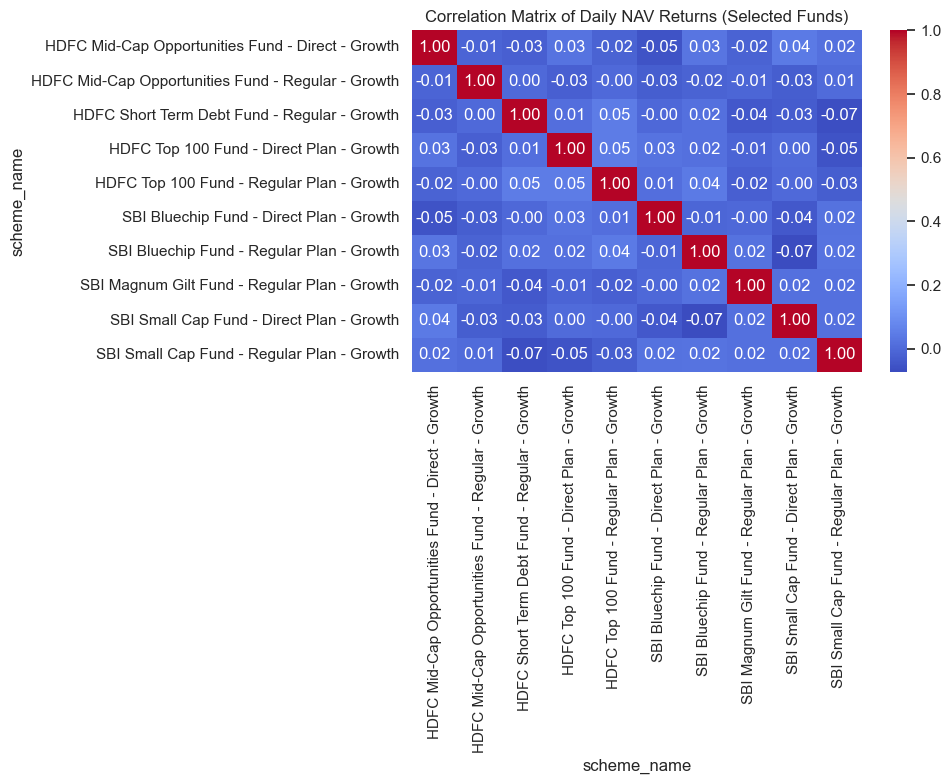

In [89]:
# Select 10 mutual fund schemes
selected_funds = fund_master["amfi_code"].head(10)

# Filter NAV data
nav_selected = nav_data[
    nav_data["amfi_code"].isin(selected_funds)
]

# Calculate daily returns
nav_returns = (
    nav_selected
    .pivot(index="date", columns="scheme_name", values="nav")
    .pct_change()
)

# Calculate correlation matrix
correlation_matrix = nav_returns.corr()

# Create the heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (Selected Funds)")

plt.tight_layout()

plt.savefig(
    "../charts/correlation/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 11 (Based on NAV Return Correlation Matrix)

Most of the selected mutual fund schemes show a **strong positive correlation** in their daily returns, indicating that they tend to move in the same direction under similar market conditions. A few fund pairs exhibit comparatively lower correlations, suggesting some diversification benefits.

# 12. Sector Allocation

In [91]:
# total sector allocation

sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

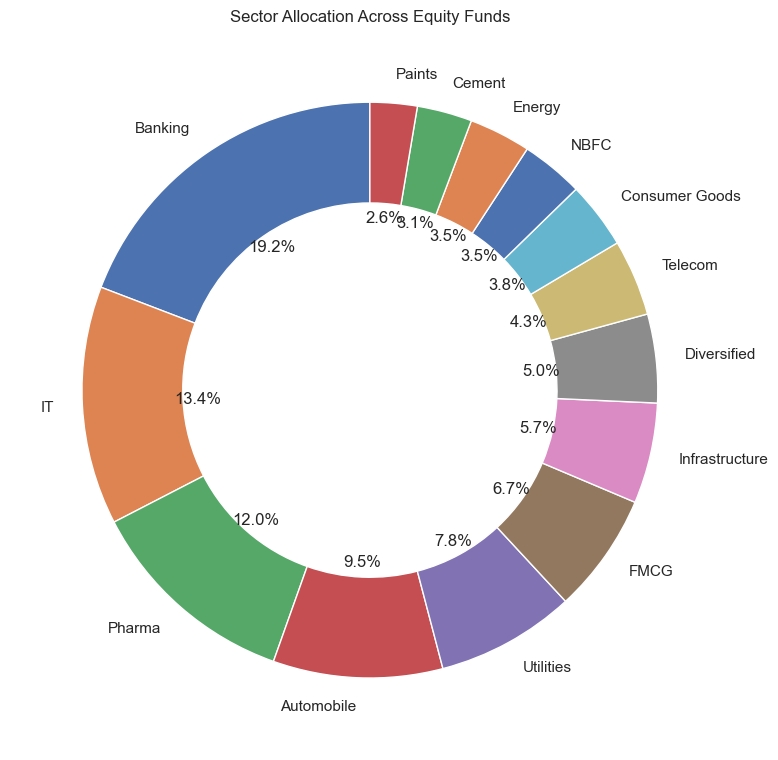

In [94]:

# a donut chart for sector allocation

plt.figure(figsize=(8, 8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.35)
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "../charts/sector/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 12 (Based on Sector Allocation)

The **Banking sector accounts for the largest portfolio allocation (19.2%)** across the selected equity mutual funds, followed by **IT (13.4%)** and **Pharma (12.0%)**. This indicates that financial services and technology remain the dominant sectors in mutual fund portfolios.